## Precipitation DownscalingDevelopment
Downscale the precipitation using SNOTEL data. Includes gap filling.

In [1]:
%matplotlib ipympl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date, time
from buildforcing.datasets import PNNLSnotel, siteNLDAS
import os

In [2]:
site = 'Quemazon'

In [ ]:
# Alpine Environmental Vars since it cannot load conda for some unknown reason
os.environ['SNOTEL_PATH'] = '/projects/ccox1@xsede.org/data/snotel'
os.environ['NLDAS_PATH'] = '/projects/ccox1@xsede.org/data/nldas'

### Load Data
I only care about the range of data used in the downscaling, so I'll limit the data to that range using the find_usable_dates function from buildforcing.

In [3]:
snotel = PNNLSnotel(site_name=site, storage_path=os.environ['SNOTEL_PATH'])
snotel.load_data()

# print latitude and longitude for reference
print(f"Latitude: {snotel.latitude}, Longitude: {snotel.longitude}")

Latitude: 35.92, Longitude: -106.39


In [4]:
start_date, end_date = snotel.find_usable_dates()
print(f"Usable dates: {start_date} to {end_date}")

Usable dates: 1989-10-01 to 2021-09-30


In [5]:
# Extract SNOTEL data for the usable date range or starting in 1990, whichever is later
if start_date < date(1990, 1, 1):
    start_date = date(1990, 1, 1)

snotel_data = snotel.data[start_date.strftime('%Y-%m-%d'):end_date.strftime('%Y-%m-%d')]

Load NLDAS data

In [6]:
nldas = siteNLDAS(snotel.latitude, snotel.longitude, start_date=datetime.combine(start_date,time(0,0)), end_date=datetime.combine(end_date,time(23,0)))
nldas.loadNetCDF(os.environ['NLDAS_PATH'])

In [ ]:
nldas.data.tail()

In [7]:
nldas_hourly_precip = nldas.data['Rainf'].tz_convert(snotel_data.index.tz)

In [8]:
nldas_precip_daily = nldas_hourly_precip.resample('D').sum()

#### Visualization

In [ ]:
snotel_data.head()

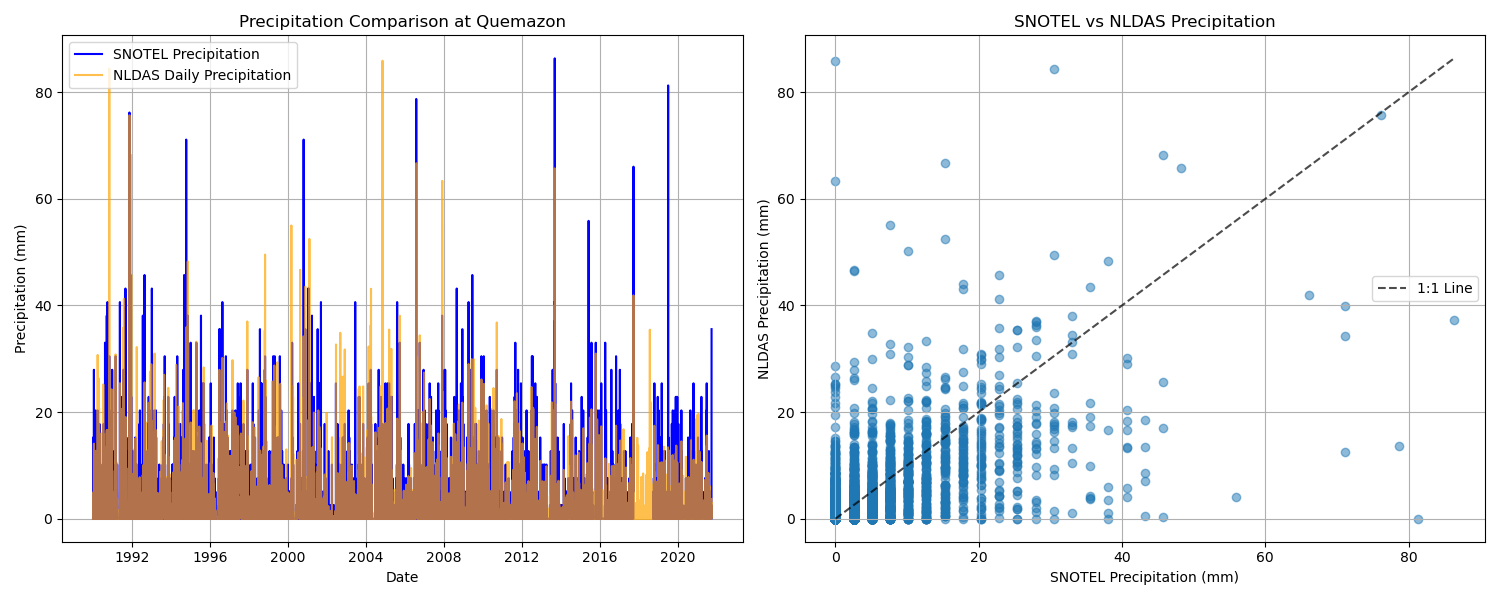

In [9]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Time series comparison
ax1.plot(snotel_data.index, snotel_data['precip_mm'], label='SNOTEL Precipitation', color='blue')
ax1.plot(nldas_precip_daily.index, nldas_precip_daily, label='NLDAS Daily Precipitation', color='orange', alpha=0.7)
ax1.set_xlabel('Date')
ax1.set_ylabel('Precipitation (mm)')
ax1.set_title(f'Precipitation Comparison at {site}')
ax1.legend()
ax1.grid(True)

# Plot 2: Scatter plot
# Create a common date range for both datasets
# Find overlapping dates by using the indexes directly
common_dates = pd.DatetimeIndex(sorted(set(snotel_data.index) & set(nldas_precip_daily.index)))

# Extract the precipitation data for the common dates
snotel_precip = snotel_data.loc[common_dates, 'precip_mm']
nldas_precip = nldas_precip_daily.loc[common_dates]

# Create scatter plot
ax2.scatter(snotel_precip, nldas_precip, alpha=0.5)
ax2.set_xlabel('SNOTEL Precipitation (mm)')
ax2.set_ylabel('NLDAS Precipitation (mm)')
ax2.set_title('SNOTEL vs NLDAS Precipitation')

# Add 1:1 line
max_val = max(snotel_precip.max(), nldas_precip.max())
ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='1:1 Line')
ax2.legend()
ax2.grid(True)

plt.tight_layout()


Monthly analysis

In [10]:
# Resample to monthly totals, remove timezone since it is not needed for monthly data
snotel_monthly = snotel_data['precip_mm'].tz_localize(None).resample('ME').sum()
nldas_monthly = nldas_precip_daily.tz_localize(None).resample('ME').sum()

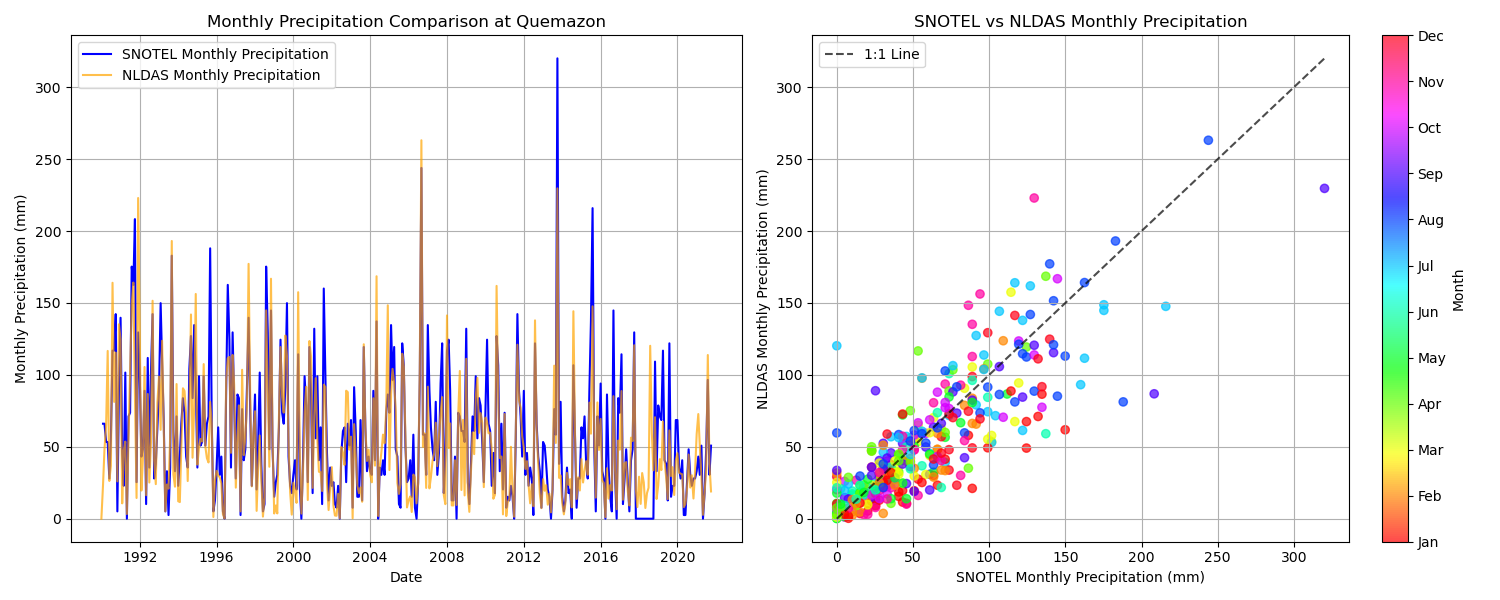

In [11]:
# Monthly totals and scatter plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot 1: Monthly time series comparison
ax1.plot(snotel_monthly.index, snotel_monthly, label='SNOTEL Monthly Precipitation', color='blue')
ax1.plot(nldas_monthly.index, nldas_monthly, label='NLDAS Monthly Precipitation', color='orange', alpha=0.7)
ax1.set_xlabel('Date')
ax1.set_ylabel('Monthly Precipitation (mm)')
ax1.set_title(f'Monthly Precipitation Comparison at {site}')
ax1.legend()
ax1.grid(True)
# Plot 2: Monthly scatter plot
# Create a common date range for both datasets
common_months = pd.DatetimeIndex(sorted(set(snotel_monthly.index) & set(nldas_monthly.index)))

# Extract the precipitation data for the common months
snotel_precip = snotel_monthly.loc[common_months]
nldas_precip = nldas_monthly.loc[common_months]

# Create scatter plot with colors by month
months = [date.month for date in common_months]
scatter = ax2.scatter(snotel_precip, nldas_precip, c=months, cmap='hsv', alpha=0.7)
ax2.set_xlabel('SNOTEL Monthly Precipitation (mm)')
ax2.set_ylabel('NLDAS Monthly Precipitation (mm)')
ax2.set_title('SNOTEL vs NLDAS Monthly Precipitation')

# Add colorbar to show month legend
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Month')
cbar.set_ticks(range(1, 13))
cbar.set_ticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Add 1:1 line
max_val = max(snotel_precip.max(), nldas_precip.max())
ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='1:1 Line')
ax2.legend()
ax2.grid(True)

plt.tight_layout()


### Algorithm Development and Testing

In [12]:
# Recalculate some variables to match the algorithm
# Convert to snotel timezone
nldas_hourly_precip_mm = nldas.data['Rainf'].tz_convert(snotel_data.index.tz)

# Track the number of naN values in the snotel data
snotel_daily_df = snotel_data['precip_mm'].rename('snotel').to_frame()
snotel_daily_df['snotel_nan'] = snotel_daily_df.isna()

# Resample the NLDAS and Snotel to monthly totals
nldas_monthly = nldas_hourly_precip_mm.resample('ME').sum()
snotel_monthly = snotel_daily_df.resample('ME').sum()


In [13]:
# Merge the monthly data to find the scaling factor
nldas_monthly.name = 'nldas'
nldas_monthly_df = pd.merge(nldas_monthly, snotel_monthly, how='left', left_index=True, right_index=True)
nldas_monthly_df['scaling_factor'] = nldas_monthly_df['snotel'] / nldas_monthly_df['nldas']

In [14]:
# Use only months where number of NaN values is below the threshold
nan_threshold = 5
regression_data = nldas_monthly_df[nldas_monthly_df['snotel_nan'] <= nan_threshold]
    
# Perform linear regression using numpy
slope, intercept = np.polyfit(regression_data['nldas'], regression_data['snotel'], 1)
linear_model = np.poly1d((slope, intercept))

# Apply regression model to months where missing data is above the threshold
nldas_nan_snotel = nldas_monthly_df['nldas'][nldas_monthly_df['snotel_nan'] > nan_threshold]
regression_scaling_factor = linear_model(nldas_nan_snotel)/nldas_nan_snotel
nldas_monthly_df.loc[nldas_monthly_df['snotel_nan'] > nan_threshold, 'scaling_factor'] = regression_scaling_factor

Text(0.5, 0, 'NLDAS Monthly Precipitation (mm)')

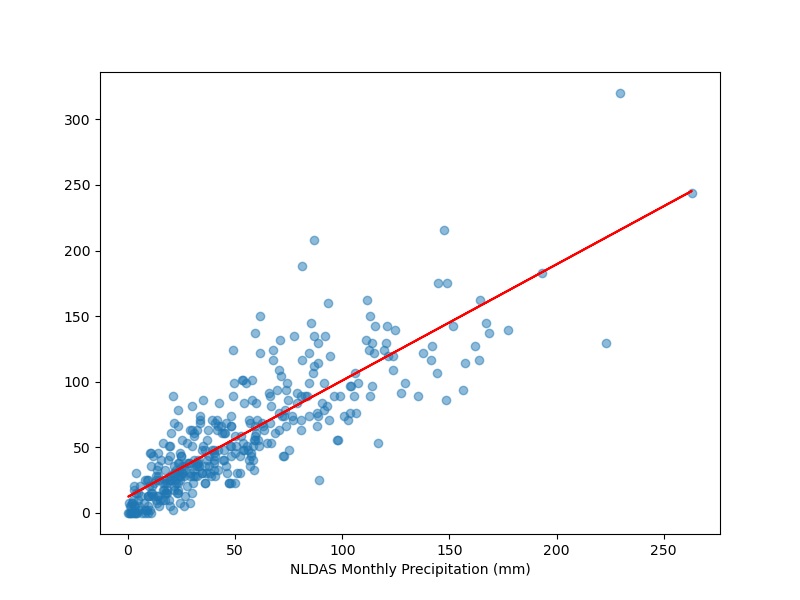

In [15]:
# Plot regression results
plt.figure(figsize=(8, 6))
plt.scatter(regression_data['nldas'], regression_data['snotel'], alpha=0.5, label='Data Points')
plt.plot(regression_data['nldas'], linear_model(regression_data['nldas']), color='red', label='Regression Line')
plt.xlabel('NLDAS Monthly Precipitation (mm)')

In [16]:
# Handle edge case - If NLDAS has no precip, scaling factor will be infinity, set to zero
nldas_monthly_df['scaling_factor'] = nldas_monthly_df['scaling_factor'].replace([np.inf, -np.inf], 0.0)

# Upscale the scaling factor to hourly data
# This is done by repeating the monthly scaling factor for each hour in the month
nldas_scaling_factor = nldas_monthly_df['scaling_factor'].resample('h').bfill()
nldas_scaling_factor.name = 'scaling_factor'

# Create a dataframe with the scaling factor for each hour
nldas_hourly_precip_mm.name = 'nldas_hourly'
nldas_hourly = pd.merge(nldas_hourly_precip_mm, nldas_scaling_factor, how='left', left_index=True, right_index=True)

# Forward fill the scaling factor to fill in any missing values
# This is required even when upsampling the scaling factor to hourly data because the upsampled data may not have the same index as the original data
nldas_hourly['scaling_factor'] = nldas_hourly['scaling_factor'].ffill()

# Multiply the NLDAS hourly data by the scaling factor for each hour
nldas_hourly['downscaled'] = nldas_hourly['nldas_hourly'] * nldas_hourly['scaling_factor']

Visualize the results

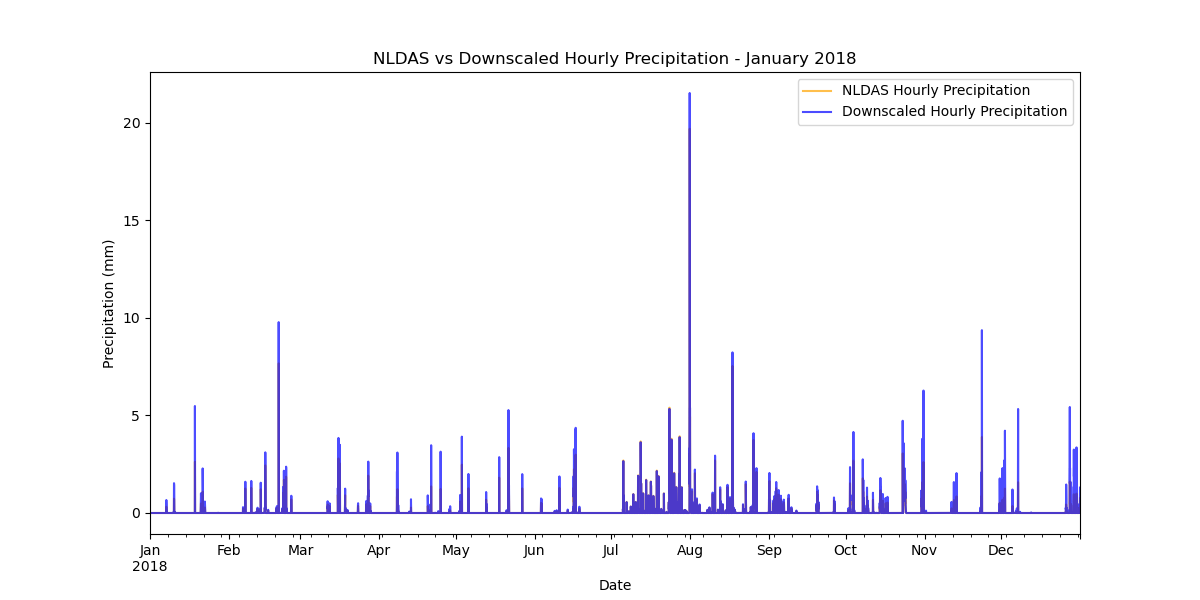

In [18]:
# Plot a year of hourly data
plt.figure(figsize=(12, 6))
nldas_hourly['nldas_hourly']['2018'].plot(label='NLDAS Hourly Precipitation', color='orange', alpha=0.7)
nldas_hourly['downscaled']['2018'].plot(label='Downscaled Hourly Precipitation', color='blue', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.title('NLDAS vs Downscaled Hourly Precipitation - January 2018')
plt.legend()
plt.show()

Compare the downscaled data to the original snotel data

In [19]:
nldas_downscaled_daily = nldas_hourly['downscaled'].resample('D').sum()
nldas_downscaled_daily.name = 'nldas_downscaled_daily'

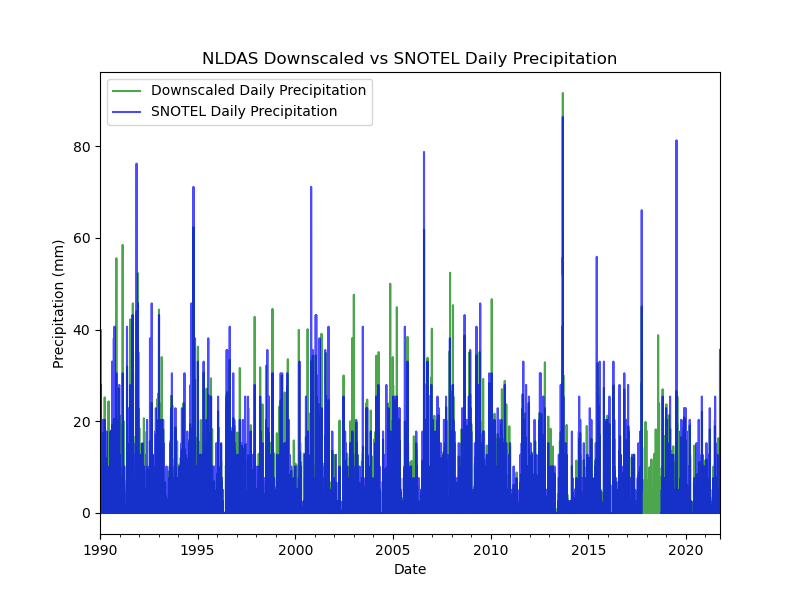

In [20]:
plt.figure(figsize=(8, 6))
nldas_downscaled_daily.plot(label='Downscaled Daily Precipitation', color='green', alpha=0.7)
snotel_data['precip_mm'].plot(label='SNOTEL Daily Precipitation', color='blue', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.title('NLDAS Downscaled vs SNOTEL Daily Precipitation')
plt.legend()
plt.show()